# Chapter 2 &mdash; Zero-Dimensional Cellular Automata

A 0-dimensional CA has a lattice of a **single cell**. That sounds
trivial &mdash; but a discrete function $f$ iterated on
$\mathbb{Z}_n$ *is* a 0-D CA, and these **finite dynamical
systems** already show off cycles, transients, basins of
attraction, and entropy &mdash; the whole conceptual toolkit we
reuse in every later chapter.

The state is a single integer $X_t \in \{0,\dots,n-1\}$, evolving by
$$ X_{t+1} = f(X_t) \bmod n. $$

In [1]:
# Setup: put the cadyn package on the path and enable inline figures.
# If you installed the package (`pip install -e .` from the repo root),
# the sys.path line is unnecessary.
import sys, pathlib
repo = pathlib.Path.cwd()
for _ in range(4):                      # find the repo root from anywhere
    if (repo / "cadyn").is_dir():
        break
    repo = repo.parent
sys.path.insert(0, str(repo))

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
from cadyn import fds

## Trajectories, cycles, and transients

Because there are only $n$ possible states, every trajectory must
eventually repeat &mdash; it falls into a **cycle**. The part
before the cycle is the **transient**. Let's watch this for
$f(x)=x^2+1 \pmod{17}$ starting at $x=0$.

In [3]:
s = fds.example_2_1()               # f(x) = x^2 + 1 (mod 17)
traj = s.trajectory(0)
print("trajectory:", traj)
print("the value", traj[-1], "recurs -> the tail is the attractive cycle")
print("cycles found:", s.cycles())

trajectory: [0, 1, 2, 5, 9, 14, 10, 16, 2]
the value 2 recurs -> the tail is the attractive cycle
cycles found: [[2, 5, 9, 14, 10, 16]]


## The basin of attraction field

Draw *every* state as a node with an arrow to its successor and you
get the **basin of attraction field** &mdash; the discrete analogue
of a phase portrait. Cycle edges are red, transient edges green.

(The layout is structure-aware: cycles are drawn as clean polygons
with their transient trees fanned outward, then relaxed with a
force-directed pass. See the note at the end of this notebook.)

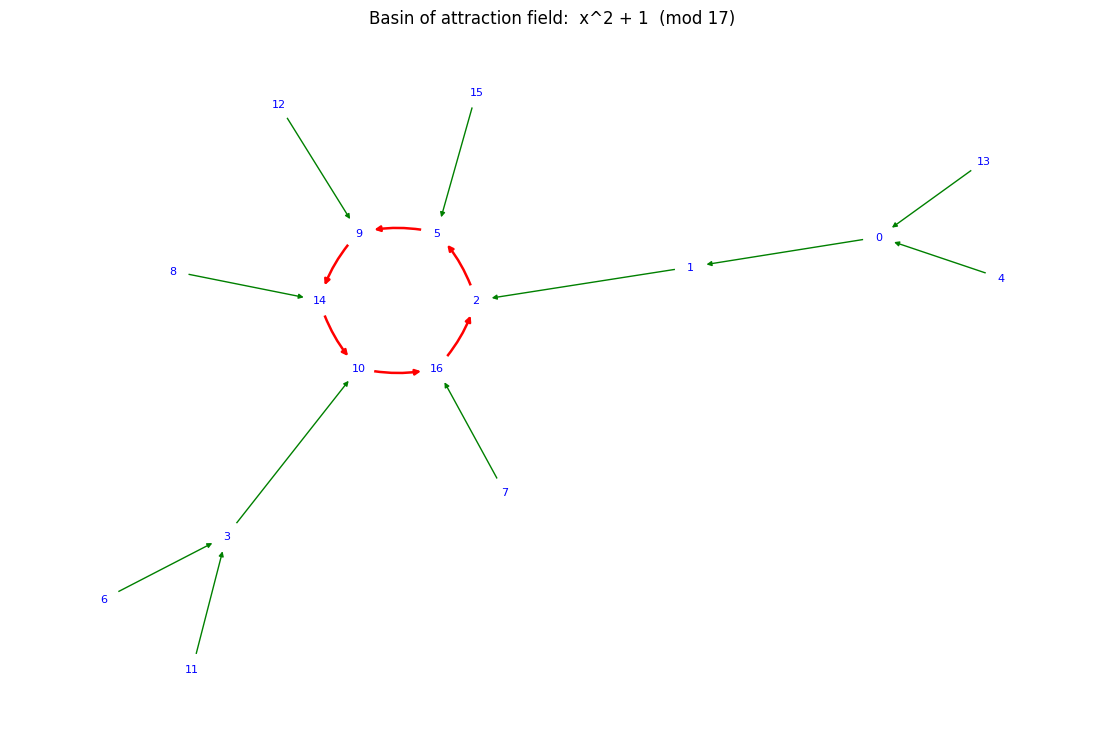

In [4]:
s.plot_basin_field()
plt.show()

Notice the eight outermost nodes with no incoming arrow. These are
**Garden of Eden** states: reachable as an initial condition but
never produced by the dynamics.

In [5]:
print("Garden of Eden states:", sorted(s.garden_of_eden_states()))

Garden of Eden states: [4, 6, 7, 8, 11, 12, 13, 15]


### A symmetry to spot

Because $x^2 = (-x)^2$ and $-x \equiv n-x \pmod n$, the two
predecessors of any node sum to $n=17$. Let's verify it.

In [6]:
g = s.to_graph()
for v in g:
    preds = list(g.predecessors(v))
    if len(preds) == 2:
        print(f"node {v:2d}: predecessors {preds} sum to {sum(preds)}")

node  0: predecessors [4, 13] sum to 17
node  2: predecessors [1, 16] sum to 17
node  3: predecessors [6, 11] sum to 17
node  5: predecessors [2, 15] sum to 17
node  9: predecessors [5, 12] sum to 17
node 10: predecessors [3, 14] sum to 17
node 14: predecessors [8, 9] sum to 17
node 16: predecessors [7, 10] sum to 17


## Shannon entropy

Start from a *uniformly random* initial state and ask: after $t$
steps, how uncertain are we about the current value? That is
Shannon's entropy
$$ H_t = -\sum_k p_t(k)\log_2 p_t(k) \quad\text{(bits)}. $$
It starts at the maximum $\log_2 n$ and **decreases** as the system
funnels into its cycles &mdash; irreversibility at work.

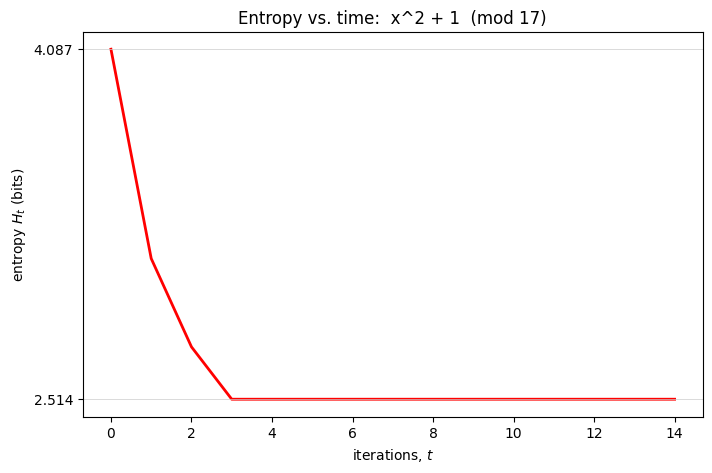

H_0 = 4.087 = log2(17) = 4.087
H_min = 2.514


In [7]:
fig, ax = plt.subplots()
s.plot_entropy(14, ax=ax)
plt.show()
H = s.entropy_curve(14)
print(f"H_0 = {H[0]:.3f} = log2(17) = {np.log2(17):.3f}")
print(f"H_min = {H.min():.3f}")

## More examples

The same function on a larger, composite modulus has a richer basin
field. $221 = 13\times 17$, and by the Chinese Remainder Theorem its
dynamics factor &mdash; producing paired cycles (two 12-cycles and
two 6-cycles).

cycle lengths: [6, 6, 12, 12]


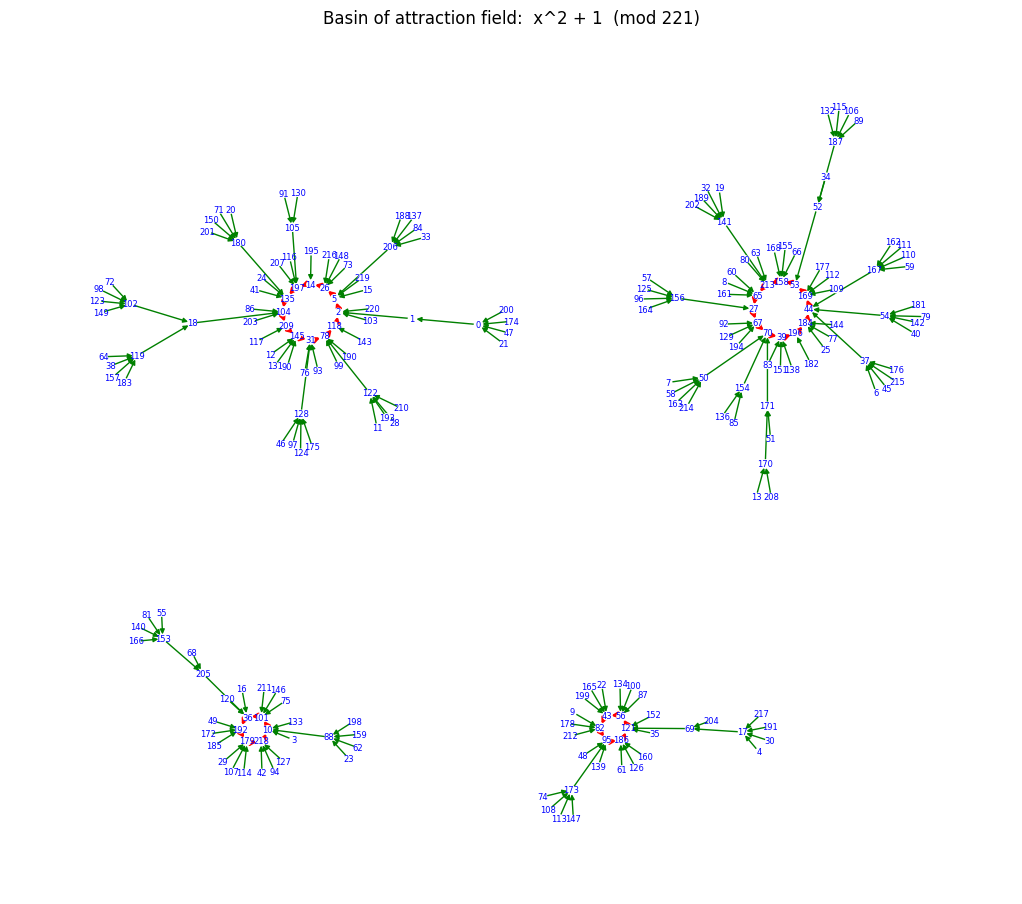

In [8]:
s221 = fds.example_2_4()            # x^2 + 1 (mod 221)
print("cycle lengths:", sorted(len(c) for c in s221.cycles()))
s221.plot_basin_field(font_size=6)
plt.show()

## The Ulam (Collatz) $3N{+}1$ function

$$ f(n) = \begin{cases} n/2 & n \text{ even}\\ 3n+1 & n\text{ odd}\end{cases} $$

Iterated on the integers it is conjectured *always* to reach the
cycle $4\to2\to1$. Computed modulo $n$, extra attractors can appear
&mdash; e.g. a surprise attractor at 23 when $n=47$.

In [9]:
for n in (20, 40, 47):
    u = fds.ulam_mod(n)
    print(f"mod {n:2d}: cycles = {[sorted(c) for c in u.cycles()]}")

mod 20: cycles = [[0], [1, 2, 4]]
mod 40: cycles = [[0], [1, 2, 4]]
mod 47: cycles = [[0], [1, 2, 4], [23]]


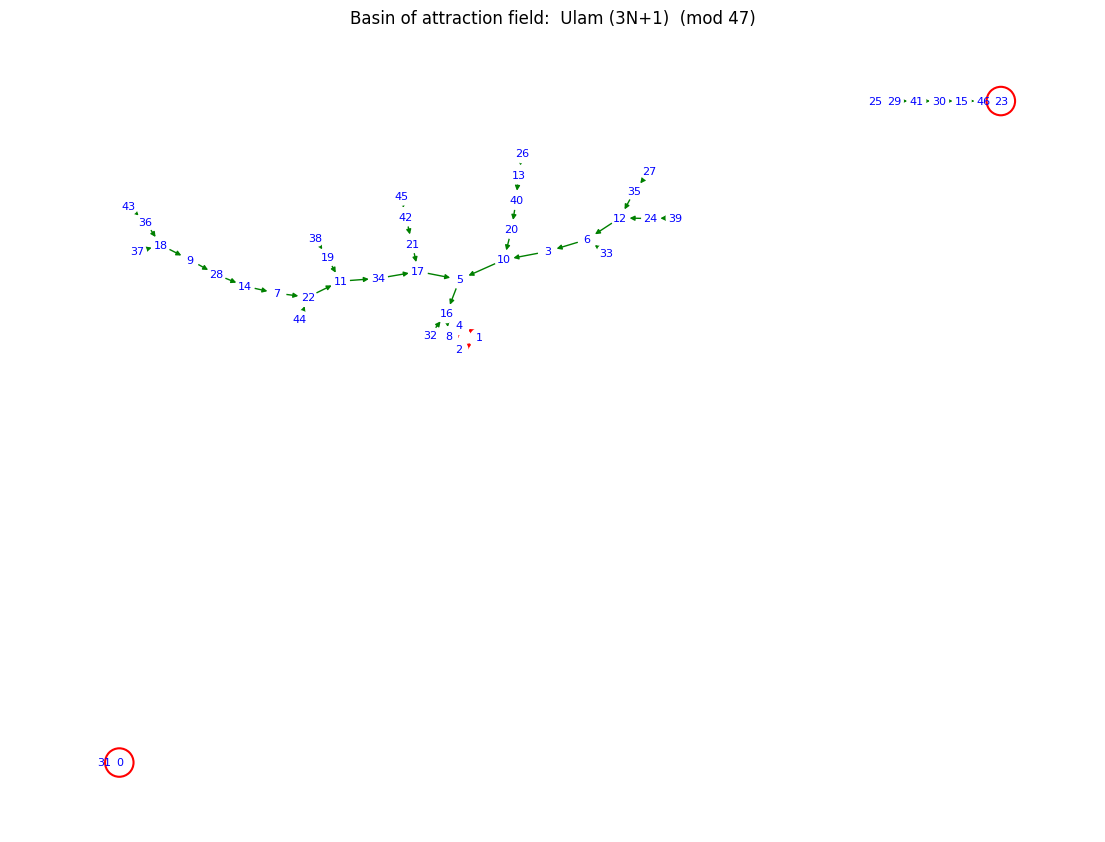

In [10]:
fds.ulam_mod(47).plot_basin_field()
plt.show()

## Your turn

1. Define your own function and wrap it in a `FiniteDynamicalSystem`:
   ```python
   g = fds.FiniteDynamicalSystem(lambda x: (x**3 + x + 1), n=29, name="x^3+x+1")
   g.plot_basin_field(); plt.show()
   ```
2. Sweep the modulus for $x^2+1$ and watch how the number and length
   of cycles change. Are prime moduli simpler?
3. Compare `refine=0` (pure radial layout) with the default
   `refine=50` (force-relaxed) in `plot_basin_field`.

> **On the layout.** The nodes repel one another while edges act as
> fixed-length struts that pivot freely &mdash; a *force-directed*
> layout. We seed it with a structure-aware radial placement (cycle
> on a circle, transient trees fanned into angular wedges) and then
> relax, holding the cycle pinned, so the picture matches the clean
> hand-drawn figures of the original 1997 book.

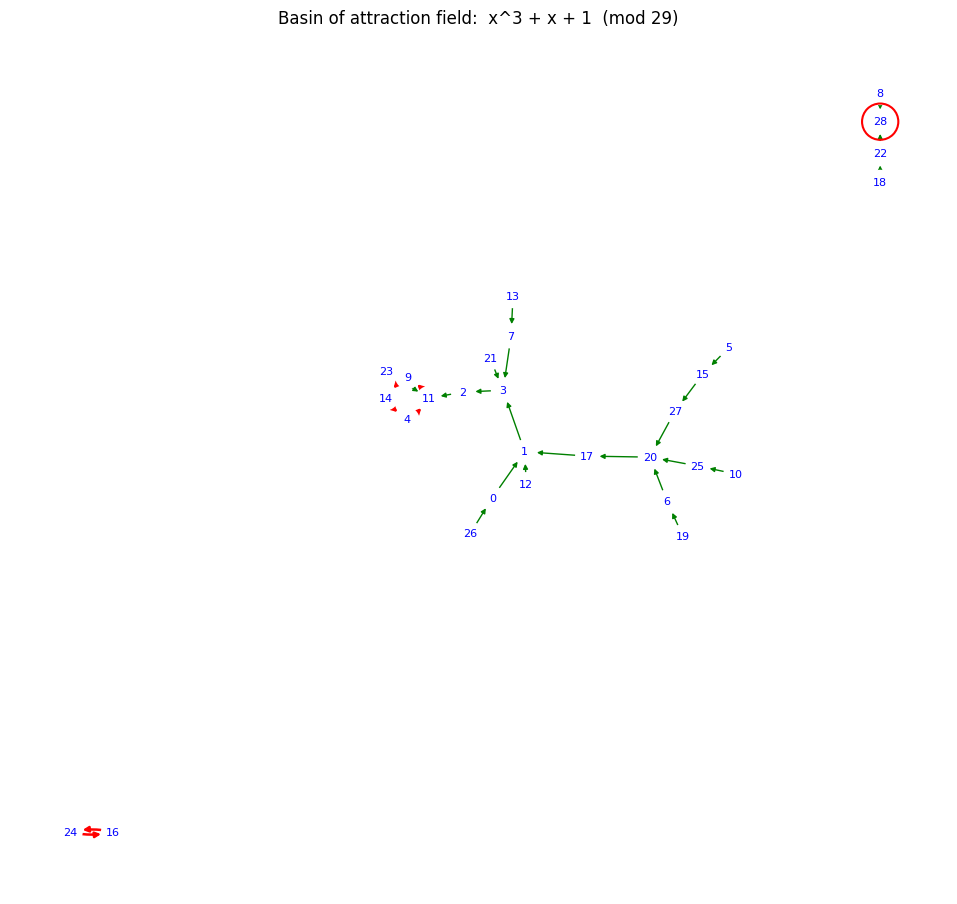

In [11]:
g = fds.FiniteDynamicalSystem(lambda x: x**3 + x + 1, n=29,
                              name="x^3 + x + 1")
g.plot_basin_field()
plt.show()